In [1]:
import sys, os
import feelpp.core as fppc
import feelpp.toolboxes.core as tb
from feelpp.toolboxes.cfpdes import *

# Set up Feel++ environment
sys.argv = ["feelpp_cfpdes_Heat2D"]
env = fppc.Environment(
    sys.argv,
    opts=tb.toolboxes_options("coefficient-form-pdes", "cfpdes"),
    config=fppc.localRepository("Heat2D")
)

def build_square_geo(fname="square.geo", L=2, h=0.02):
    half = L/2
    geo = f"""SetFactory("OpenCASCADE");
h = {h};
Rectangle(1) = {{-{half}, -{half}, 0, {L}, {L}, 0}};
Characteristic Length{{ PointsOf{{ Surface{{1}};}} }} = h;
Physical Curve("Gamma_D") = {{1,2,3,4}};
Physical Surface("Omega") = {{1}};
"""
    with open(fname, "w") as f:
        f.write(geo)

def load_mesh(fname="square.geo", h=0.02, verbose=False):
    for ext in (".geo", ".msh"):
        fp = os.path.splitext(fname)[0] + ext
        if os.path.exists(fp):
            os.remove(fp)
    if verbose:
        print(f"[Mesh] Generating {fname}  h={h}")
    build_square_geo(fname, h=h)
    return fppc.load(fppc.mesh(dim=2, realdim=2), fname, h)


def heat2d_json(order=1, alpha=0.5, u_name="u"):
    return {
        "Name": "Heat2D",
        "Models": {
            "cfpdes-2d": {"equations": "AdvDiff"},
            "AdvDiff": {
                "setup": {
                    "unknown": {"basis": f"Pch{order}", "name": u_name, "symbol": u_name},
                    "coefficients": {
                        "d": "1.",
                        "c": f"{alpha}",      # diffusion coefficient
                        "beta": "{0,0}:x:y",
                        "f": "0."             # no source term
                    }
                }
            }
        },
        "Materials": {"Omega": {"markers": ["Omega"]}},
        "BoundaryConditions": {
            "AdvDiff": {
                "Dirichlet": {
                    u_name: {"markers": ["Gamma_D"], "expr": "0"}
                }
            }
        },
    "InitialConditions": {
        "AdvDiff": {
            u_name: {
                "Expression": {
                    "wendland": {
                        "markers": ["Omega"],
                        "expr":
                            "exp(-10*((x)^2+(y)^2)):x:y"
                    }
                }
            }
        }
    },
        "PostProcess": {
            "cfpdes-2d": {
                "Exports": {
                    "fields": ["all"],
                    "save-time-step": 1      # export every step
                }
            }
        }
    }


def heat2d_cfg(dt=0.005, T=0.1, order=1):
    return f"""
case.dimensions=2
[cfpdes]
pc-type=gamg
reuse-prec=1
[cfpdes.AdvDiff.bdf]
order={order}
[ts]
time-initial = 0
time-step    = {dt}
time-final   = {T}
"""


def solve_heat2d(hsize=0.02, order=1, alpha=0.5, dt=0.005, T=0.1, verbose=True):
    # Write cfg
    with open("heat2d.cfg", "w") as f:
        f.write(heat2d_cfg(dt, T, order))

    fppc.Environment.setConfigFile("heat2d.cfg")

    model = cfpdes(dim=2, keyword="cfpdes-2d")
    mesh = load_mesh("square.geo", h=hsize, verbose=verbose)
    model.setMesh(mesh)
    model.setModelProperties(heat2d_json(order, alpha))
    model.init(buildModelAlgebraicFactory=True)

    if verbose: model.printAndSaveInfo()
    model.exportResults()

    model.startTimeStep()
    while not model.timeStepBase().isFinished():
        if verbose and model.worldComm().isMasterRank():
            print(f"--- t = {model.time():.5f}")
        model.solve()
        model.exportResults()
        model.updateTimeStep()

solve_heat2d(
    hsize=0.02,    # mesh size
    order=1,       # linear element
    alpha=0.5,     # diffusion coefficient
    dt=0.005,
    T=0.1,
    verbose=True
)


[ Starting Feel++ ] application feelpp_cfpdes_Heat2D version 0.1 date 2025-May-27
 . feelpp_cfpdes_Heat2D files are stored in /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/Heat2D/np_1
 .. logfiles :/home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/Heat2D/np_1/logs
Reading /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/Heat2D/np_1/heat2d.cfg...
[Mesh] Generating square.geo  h=0.02
[loadMesh] Loading mesh in format geo+msh: "/home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/Heat2D/np_1/square.geo"
--- t = 0.00500[loadMesh] Use default geo desc: /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/feelppdb/Heat2D/np_1/square.geo 0.02 
+-----------------------------------------------------------------------------------------------------------------------------------------+
| Toolbox::cfpdes-2d - Use Case Study                                                                                                     |
+--------------------------------------------------------------------------

⏱️ Detected 20 time frames: [0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095]


2025-05-27 05:52:55.221 (   1.237s) [    7F8033F73000]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


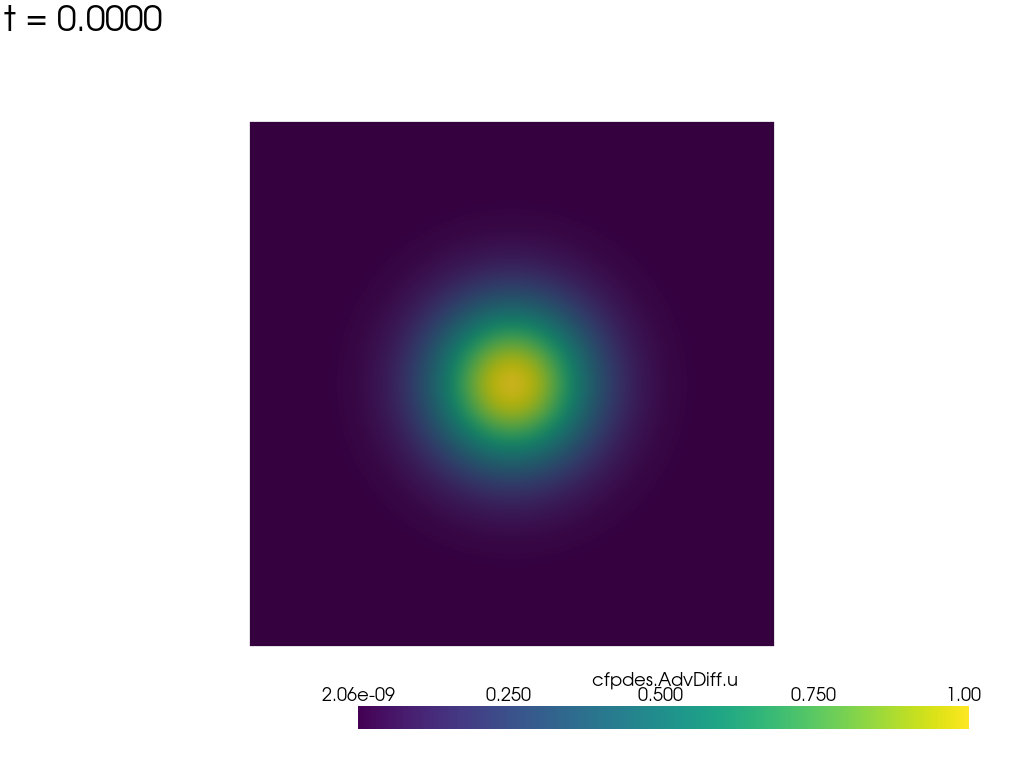

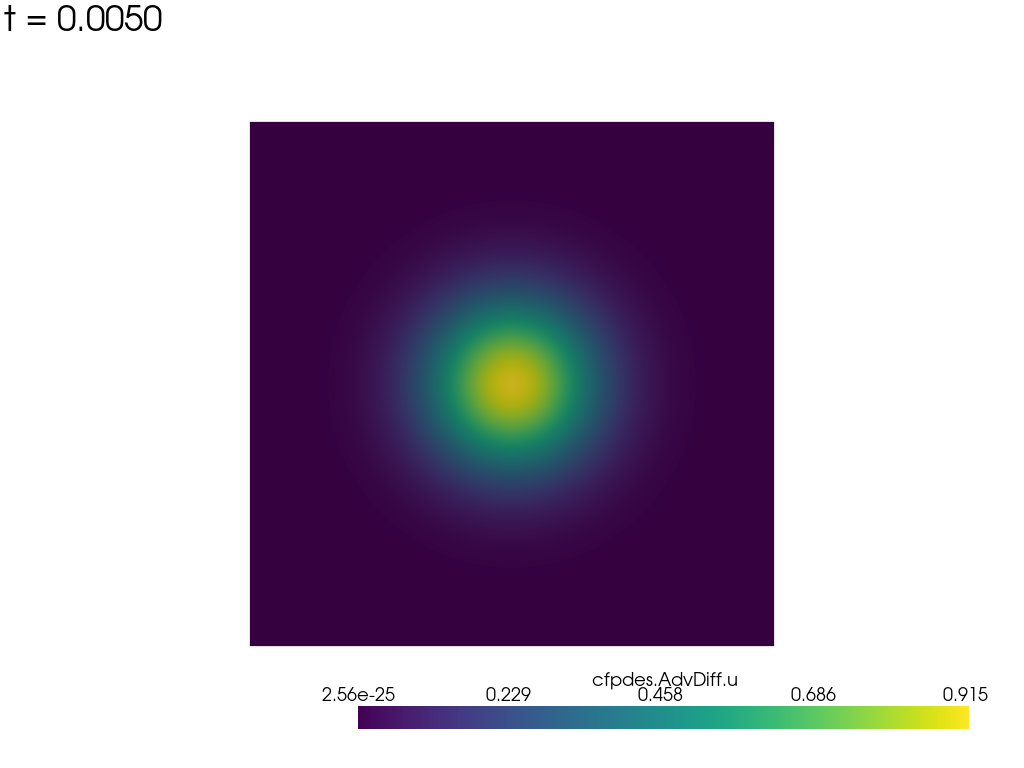

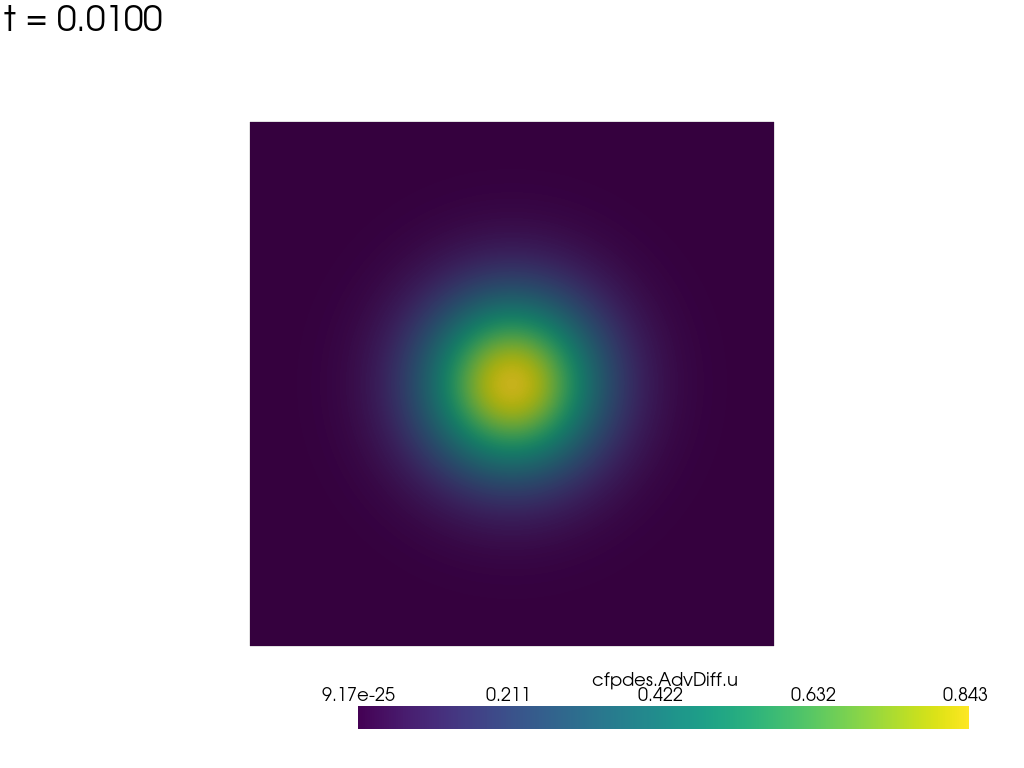

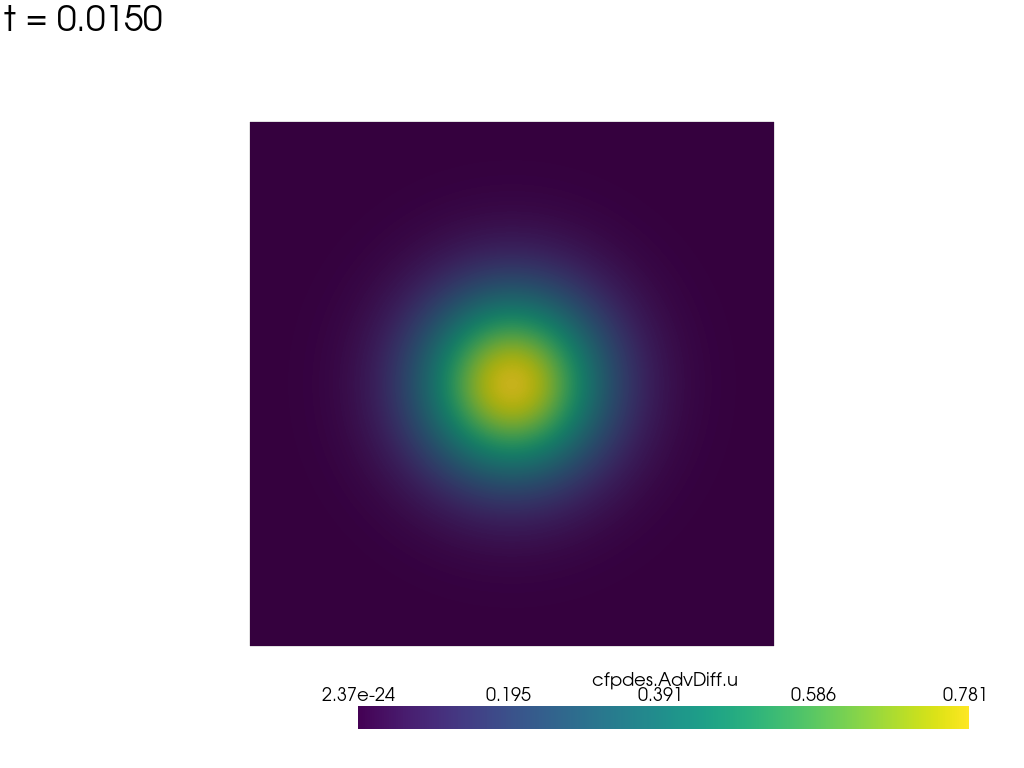

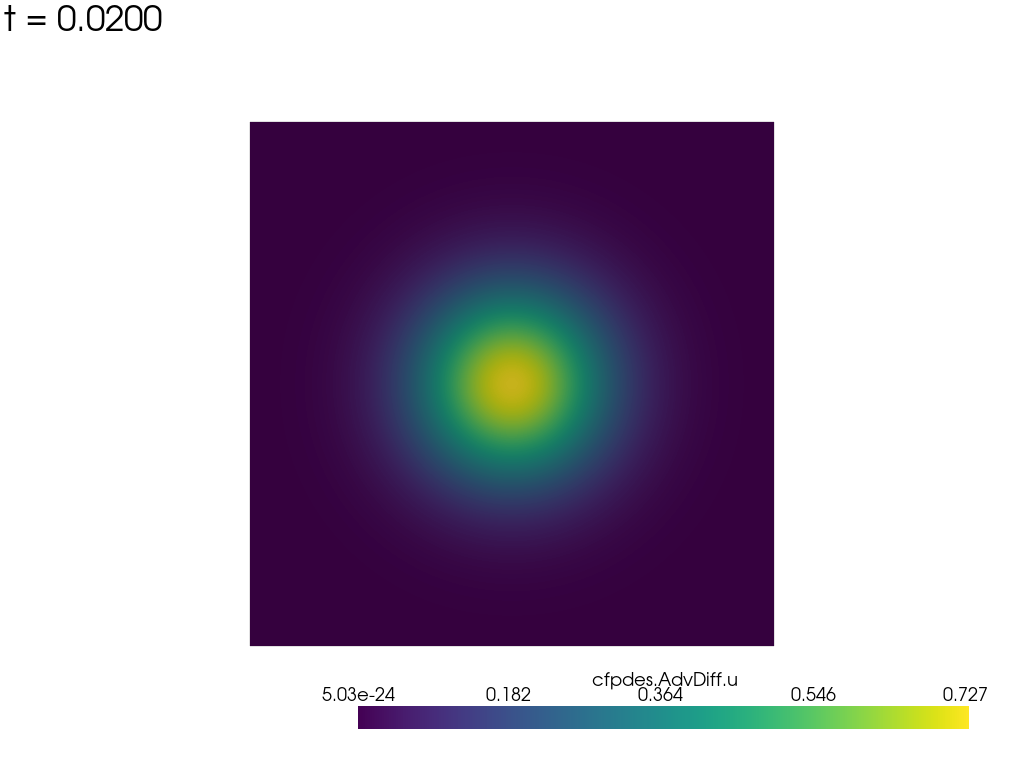

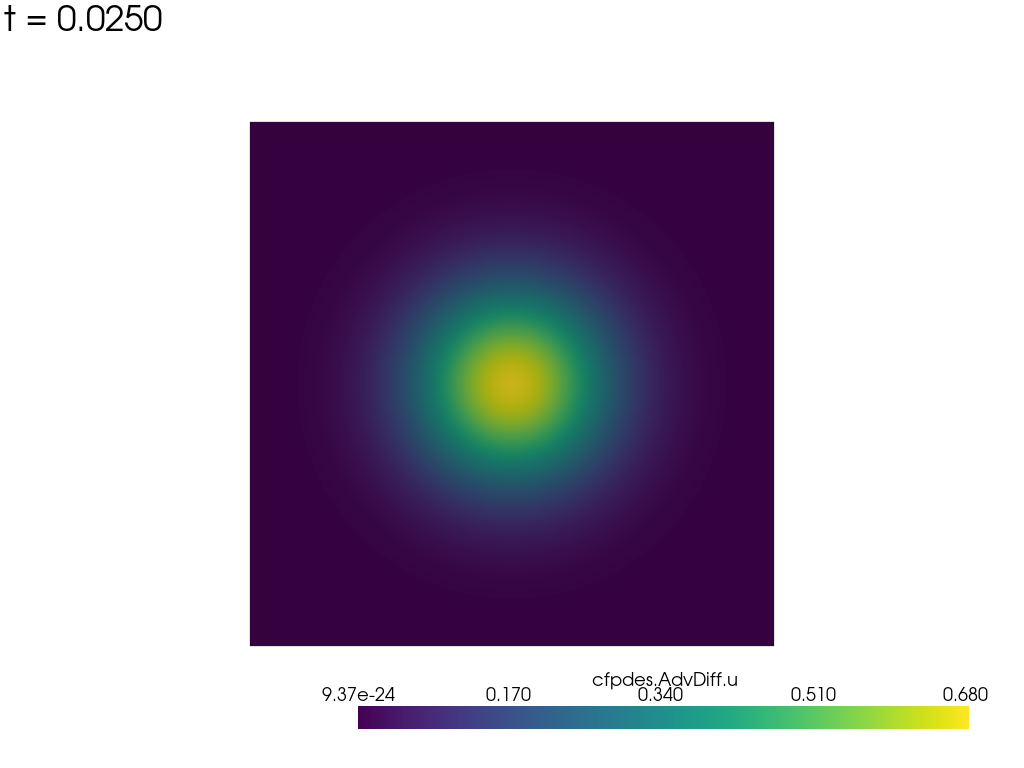

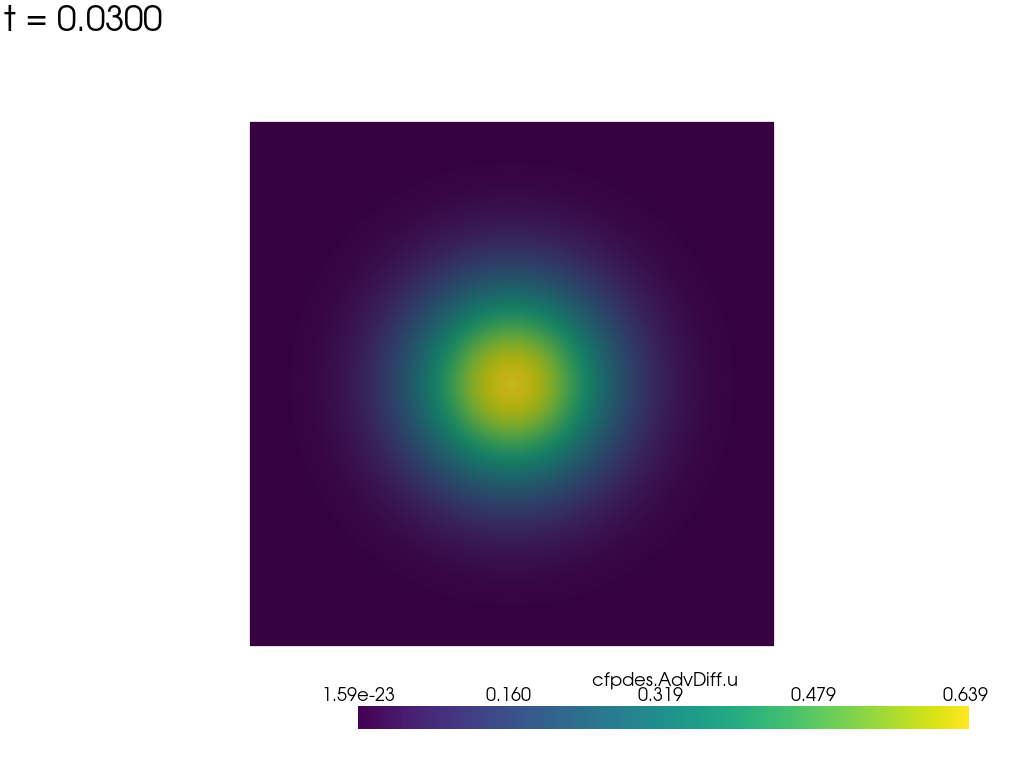

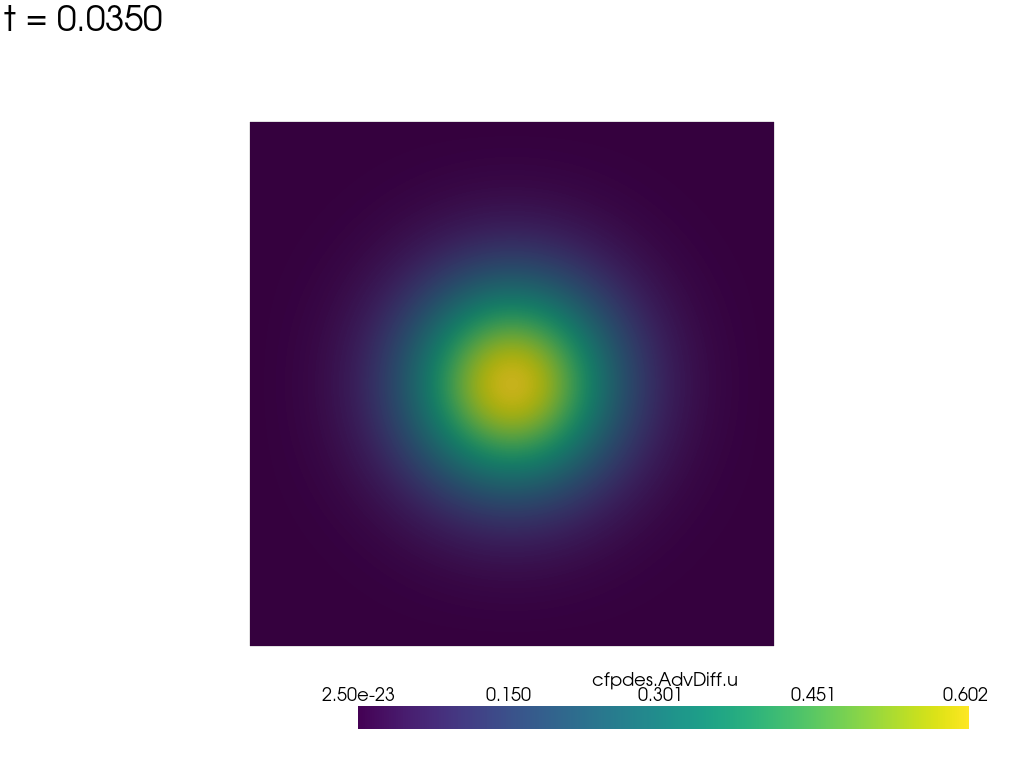

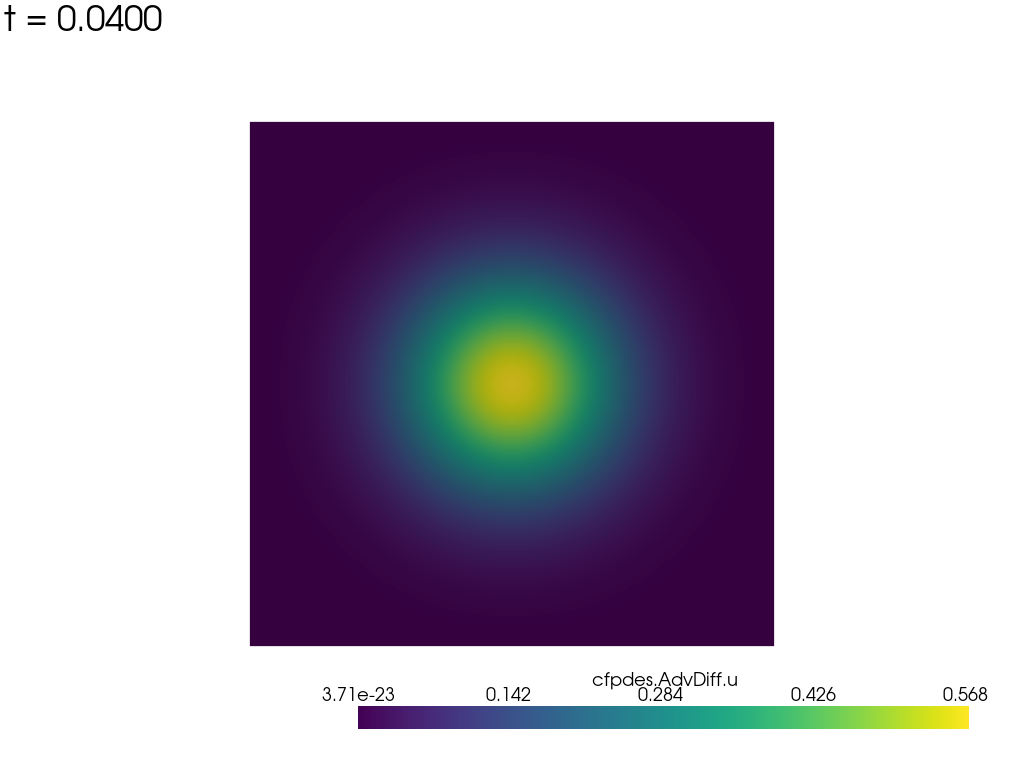

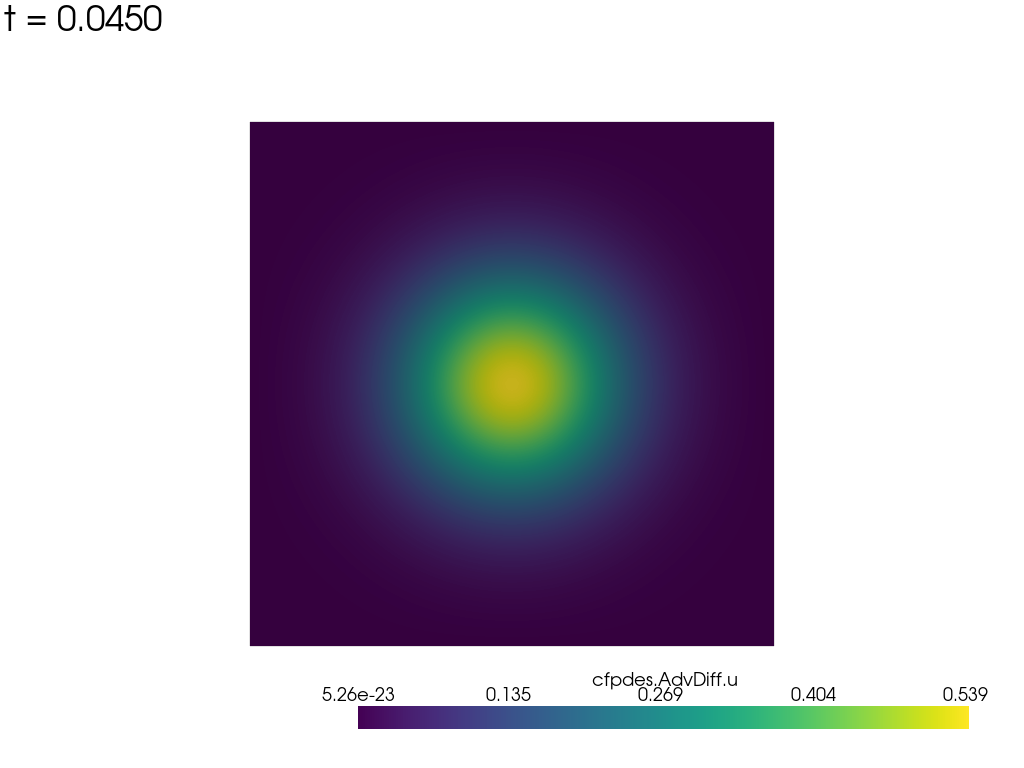

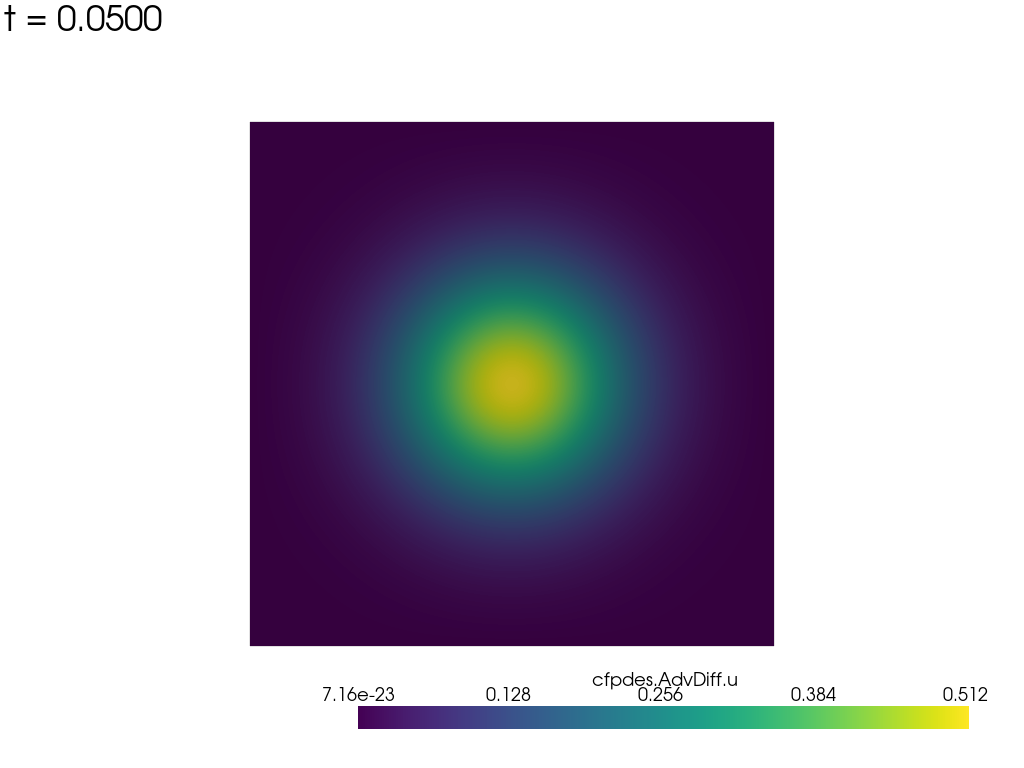

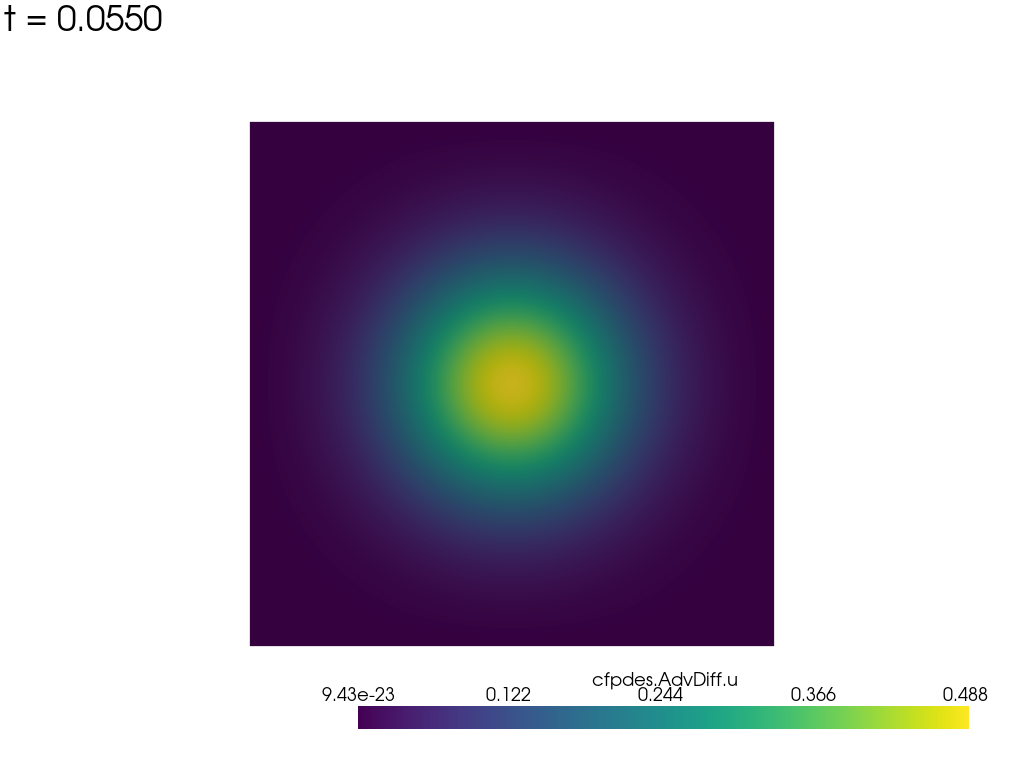

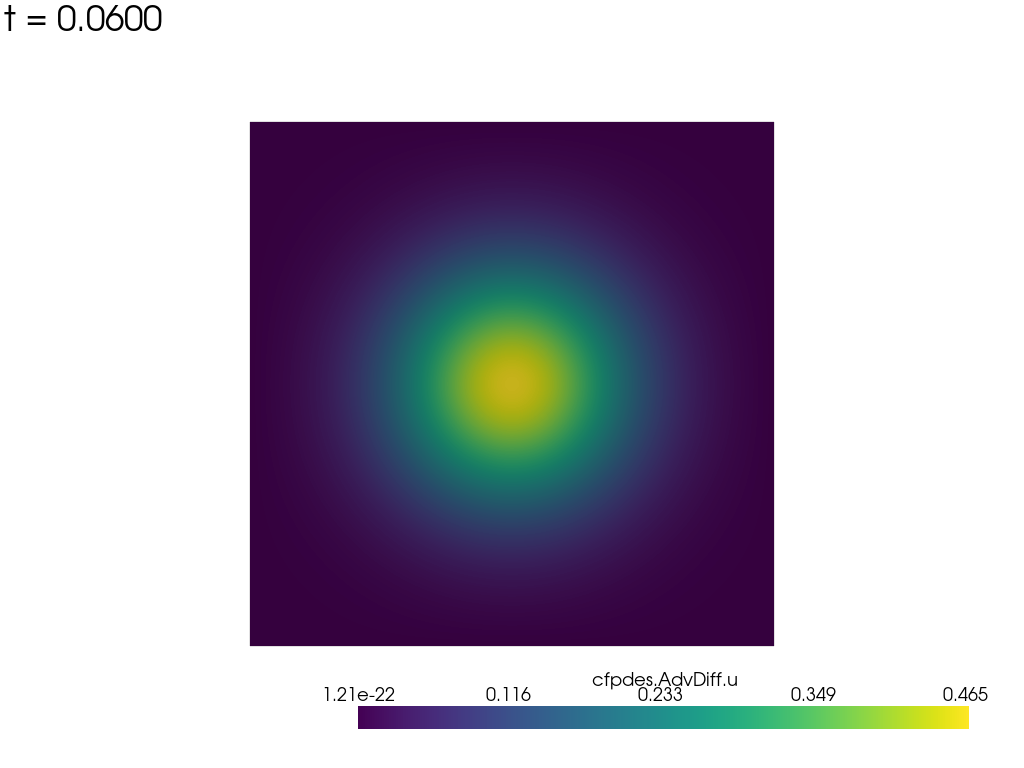

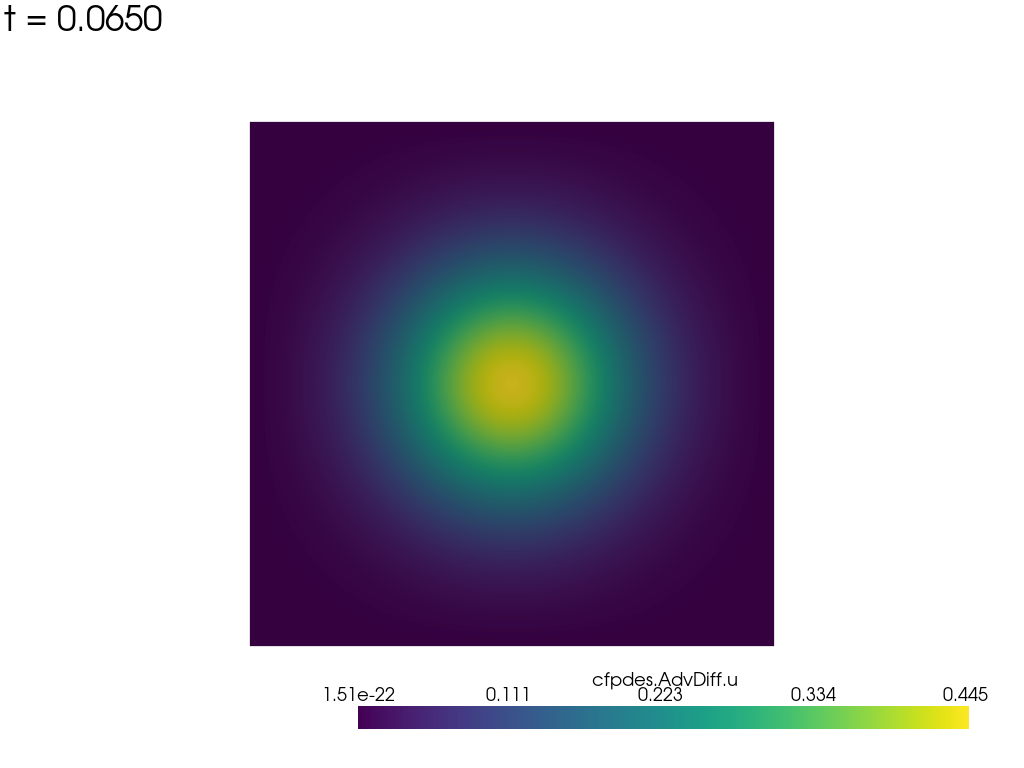

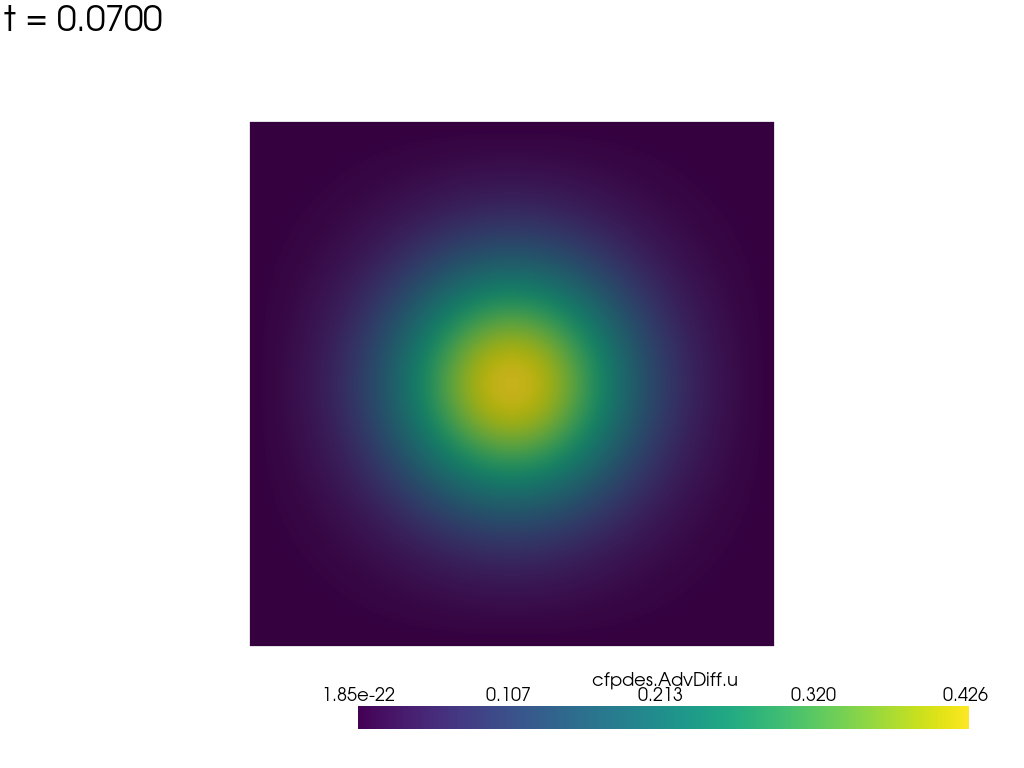

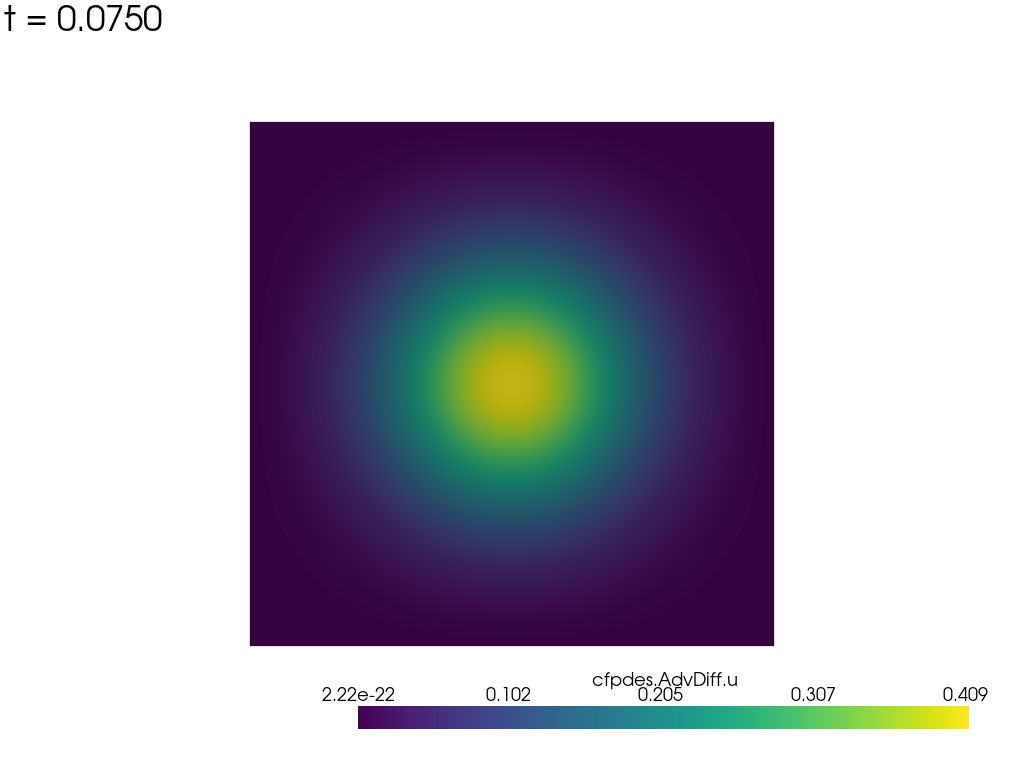

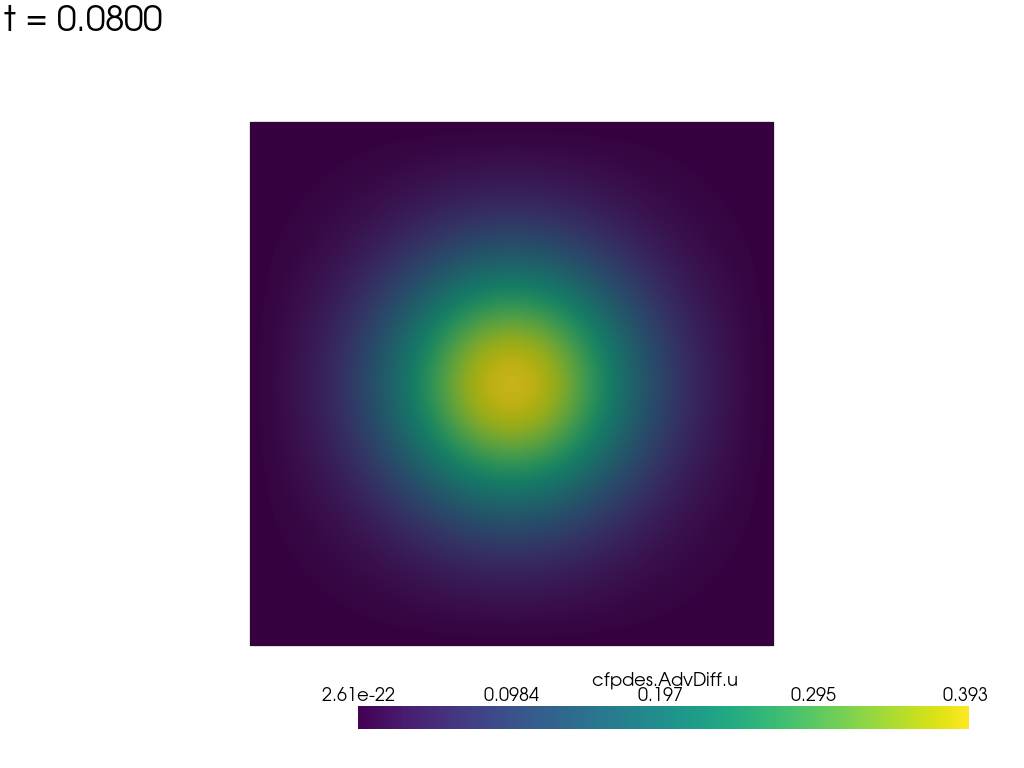

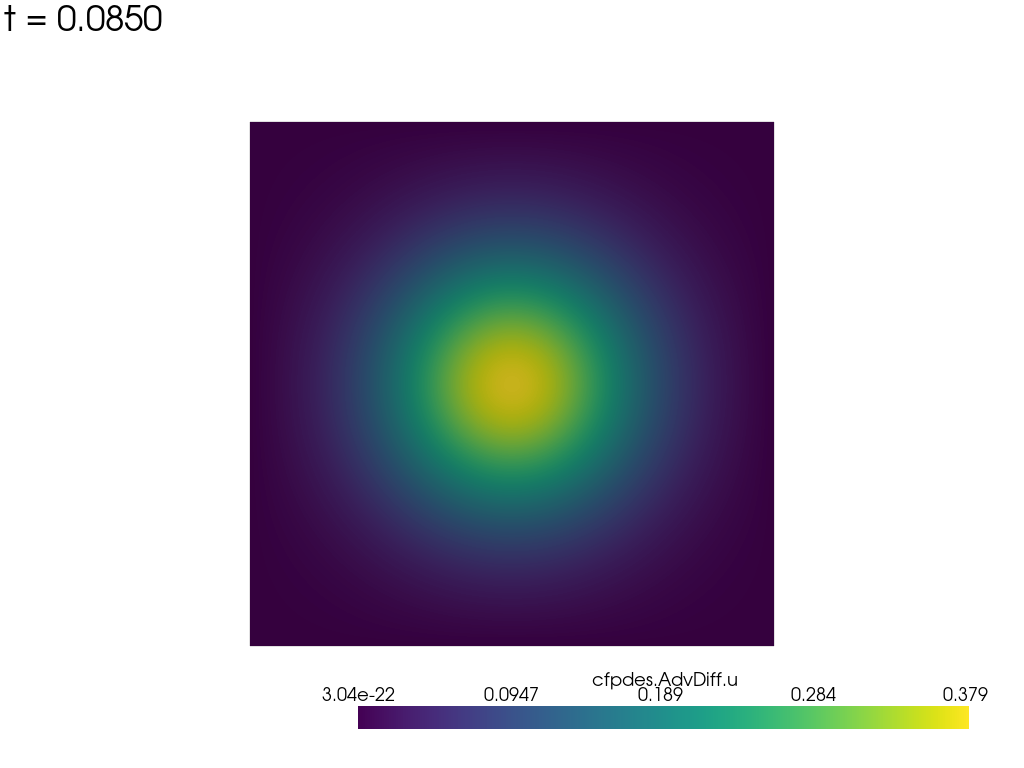

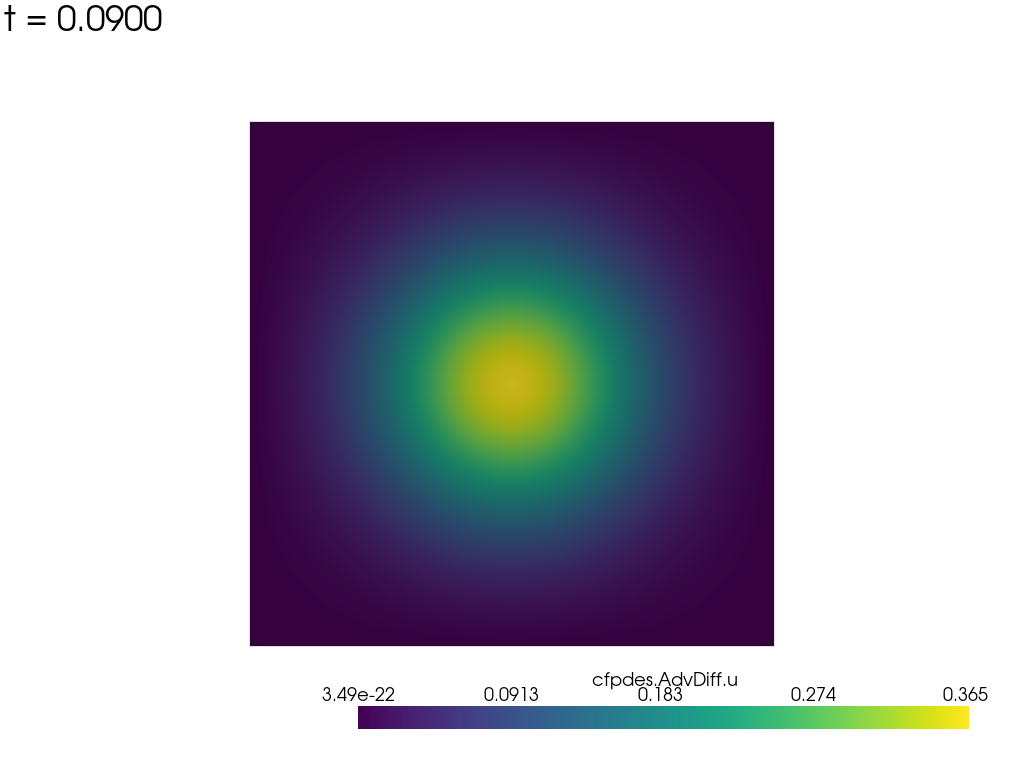

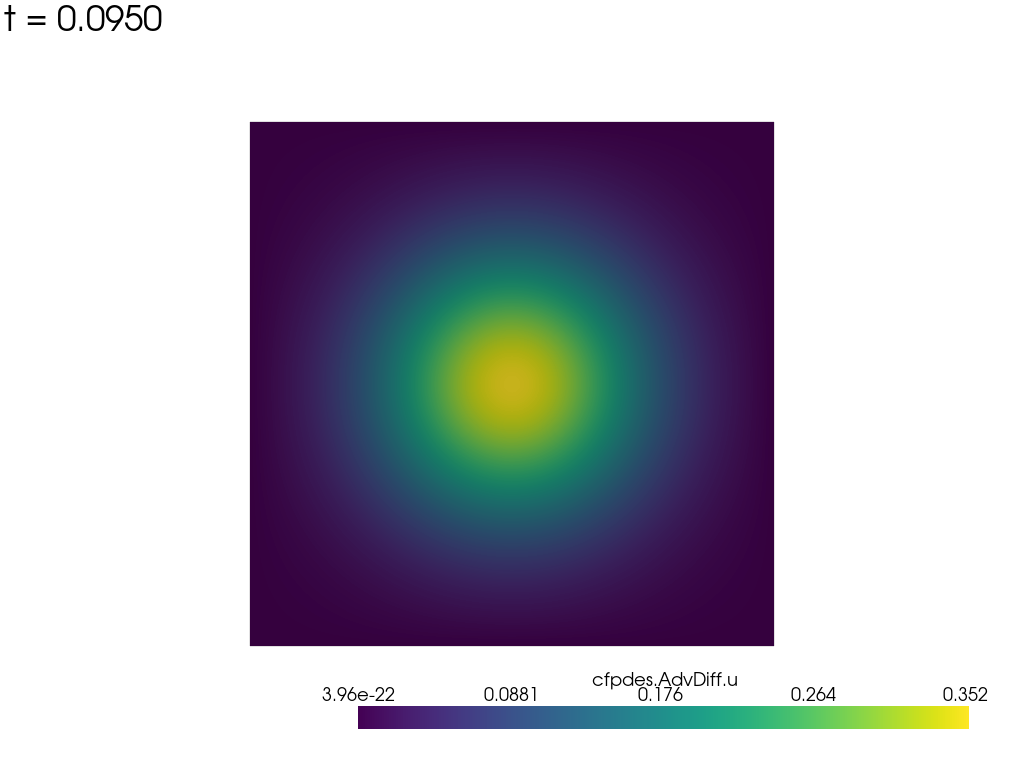

In [2]:
import pyvista as pv
import os

# Set static backend (avoid GUI errors)
pv.set_jupyter_backend('static')

# Path to .case file
case_path = os.path.abspath("cfpdes-2d.exports/Export.case")

# Create reader
reader = pv.get_reader(case_path)

# Extract time step list
time_values = reader.time_values
print(f"⏱️ Detected {len(time_values)} time frames: {time_values}")

# Display each frame
for i, t in enumerate(time_values):
    reader.set_active_time_value(t)
    mesh = reader.read()
    
    # If MultiBlock dataset, take the first block
    block = mesh[0] if isinstance(mesh, pv.MultiBlock) else mesh

    # Get scalar field names
    field_names = list(block.point_data.keys())
    if not field_names:
        print(f"⚠️ No scalar data in frame {i}")
        continue
    scalar_name = field_names[0]

    # Visualization
    p = pv.Plotter()
    p.add_mesh(block, scalars=scalar_name, cmap="viridis", show_edges=False)
    p.add_text(f"t = {t:.4f}", font_size=14)
    p.view_xy()
    p.show()
